In [57]:
import math
import torch
import numpy as np
import gpytorch
from matplotlib import pyplot as plt
from gpytorch.priors import UniformPrior
import pyro
from pyro.infer.mcmc import NUTS, MCMC
from tqdm.auto import tqdm

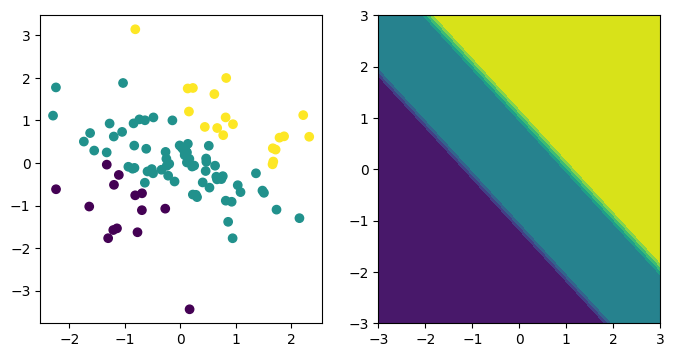

In [58]:
def gen_data(num_data, seed = 2019):
    torch.random.manual_seed(seed)

    x = torch.randn(num_data,1)
    y = torch.randn(num_data,1)

    u = torch.rand(1)
    data_fn = lambda x, y: 1 * torch.sin(0.15 * u * 3.1415 * (x + y)) + 1
    latent_fn = data_fn(x, y)
    z = torch.round(latent_fn).long().squeeze()
    return torch.cat((x,y),dim=1), z, data_fn

train_x, train_y, genfn = gen_data(100)

test_d1 = np.linspace(-3, 3, 20)
test_d2 = np.linspace(-3, 3, 20)

test_x_mat, test_y_mat = np.meshgrid(test_d1, test_d2)
test_x_mat, test_y_mat = torch.Tensor(test_x_mat), torch.Tensor(test_y_mat)

test_x = torch.cat((test_x_mat.view(-1,1), test_y_mat.view(-1,1)),dim=1)
test_labels = torch.round(genfn(test_x_mat, test_y_mat))
test_y = test_labels.view(-1)

fig, axs = plt.subplots(1,2, figsize=(4*2, 4))
axs[0].scatter(train_x[:,0].numpy(), train_x[:,1].numpy(), c = train_y)
axs[1].contourf(test_x_mat.numpy(), test_y_mat.numpy(), test_labels.numpy())
plt.show()


In [59]:
print(train_x.shape, train_y.shape, test_x.shape)

torch.Size([100, 2]) torch.Size([100]) torch.Size([400, 2])


In [60]:
from gpytorch.models import ExactGP
from gpytorch.likelihoods import DirichletClassificationLikelihood
from gpytorch.means import ConstantMean
from gpytorch.kernels import ScaleKernel, RBFKernel 

class DirichletGPModel(ExactGP):
    def __init__(self, train_x, train_y, likelihood, num_classes):
        super(DirichletGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = ConstantMean(batch_shape=torch.Size((num_classes,)))
        self.covar_module = ScaleKernel(
            RBFKernel(batch_shape=torch.Size((num_classes,))),
            batch_shape=torch.Size((num_classes,)),
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [61]:
likelihood = DirichletClassificationLikelihood(
    train_y, learn_additional_noise=True
    )
model = DirichletGPModel(train_x, 
                         likelihood.transformed_targets, 
                         likelihood, 
                         num_classes=likelihood.num_classes
                    )

In [62]:
# Add priors for sampling 
model.mean_module.register_prior(
    "mean_prior", UniformPrior(-1, 1), "constant"
    )
model.covar_module.base_kernel.register_prior(
    "lengthscale_prior", UniformPrior(0.01, 0.5), "lengthscale"
    )
model.covar_module.register_prior(
    "outputscale_prior", UniformPrior(1, 2), "outputscale"
    )
likelihood.register_prior(
    "noise_prior", UniformPrior(0.01, 0.5), "second_noise"
    )
model

DirichletGPModel(
  (likelihood): DirichletClassificationLikelihood(
    (noise_covar): FixedGaussianNoise()
    (second_noise_covar): HomoskedasticNoise(
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
    (noise_prior): UniformPrior(low: 0.009999999776482582, high: 0.5)
  )
  (mean_module): ConstantMean(
    (mean_prior): UniformPrior(low: -1.0, high: 1.0)
  )
  (covar_module): ScaleKernel(
    (base_kernel): RBFKernel(
      (raw_lengthscale_constraint): Positive()
      (lengthscale_prior): UniformPrior(low: 0.009999999776482582, high: 0.5)
    )
    (raw_outputscale_constraint): Positive()
    (outputscale_prior): UniformPrior(low: 1.0, high: 2.0)
  )
)

In [63]:
num_samples = 10
warmup_steps = 10

def pyro_model(x, y):
    with gpytorch.settings.fast_computations(False, False, False):
        sampled_model = model.pyro_sample_from_prior()
        output = sampled_model.likelihood(sampled_model(x))
        pyro.sample("obs", output, obs=y)
    return y

nuts = NUTS(pyro_model)
mcmc = MCMC(
    nuts, 
    num_samples=num_samples, 
    warmup_steps=warmup_steps, 
    disable_progbar=False
    )
mcmc.run(train_x, likelihood.transformed_targets)

Sample: 100%|██████████| 20/20 [00:01, 14.06it/s, step size=4.90e-01, acc. prob=0.960]


In [75]:
def make_predictions_with_pyro(samples, 
                               train_x, 
                               train_y, 
                               test_x, 
                            ):
    """
    Make predictions by sampling from the posterior using the pyro_model.
    This avoids all the batch dimension issues with pyro_load_from_samples.
    """
    all_predictions = []
    
    sample_keys = list(samples.keys())
    num_samples = samples[sample_keys[0]].shape[0]
        
    with tqdm(range(num_samples)) as pbar:
        for i in pbar:
            pbar.set_description(f"Sampling {i+1}/{num_samples}")
            # Extract the i-th sample from each parameter
            sample = {key: val[i] for key, val in samples.items()}
            
            # Create a new model instance for this sample (clean slate)
            likelihood = DirichletClassificationLikelihood(
                train_y, learn_additional_noise=True
            )
            model = DirichletGPModel(
                train_x, 
                likelihood.transformed_targets, 
                likelihood, 
                num_classes=likelihood.num_classes
            )
            
            # Set the parameters manually (only the actual model parameters, not priors)
            model.eval()
            likelihood.eval()
            
            with torch.no_grad():
                # Set model parameters
                if 'mean_module.constant' in sample:
                    model.mean_module.constant.data = sample['mean_module.constant']
                
                if 'covar_module.base_kernel.lengthscale' in sample:
                    model.covar_module.base_kernel.lengthscale = sample['covar_module.base_kernel.lengthscale']
                    
                if 'covar_module.outputscale' in sample:
                    model.covar_module.outputscale = sample['covar_module.outputscale']
                    
                if 'likelihood.second_noise' in sample:
                    likelihood.second_noise = sample['likelihood.second_noise']
                
                # Make prediction with this sample
                rho = model(test_x)
                all_predictions.append(rho.mean)  # Shape: [num_classes, num_test_points]
    
    # Stack all predictions: [num_samples, num_classes, num_test_points]
    return torch.stack(all_predictions, dim=0)

In [76]:
samples = mcmc.get_samples()
preds = make_predictions_with_pyro(samples, train_x, train_y, test_x)

  0%|          | 0/10 [00:00<?, ?it/s]

In [66]:
logits_transposed = preds.permute(0, 2, 1)
probabilities = torch.softmax(logits_transposed, dim=-1)  # Softmax over classes
prob_mean = probabilities.mean(0)

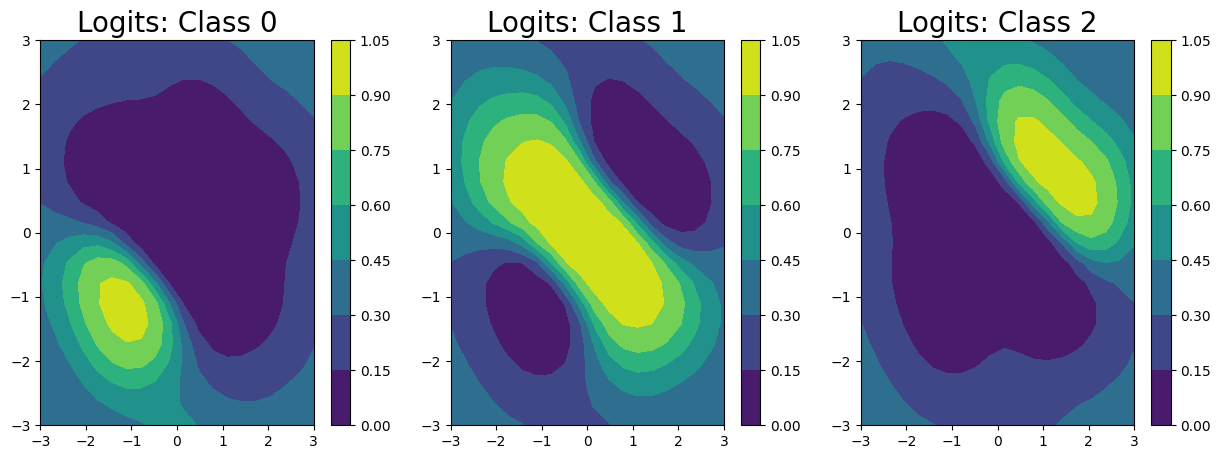

In [67]:
fig, ax = plt.subplots(1, 3, figsize = (15, 5))
for i in range(3):
    im = ax[i].contourf(
        test_x_mat.numpy(), 
        test_y_mat.numpy(), 
        prob_mean[:,i].numpy().reshape((20,20))
    )
    fig.colorbar(im, ax=ax[i])
    ax[i].set_title("Logits: Class " + str(i), fontsize = 20)

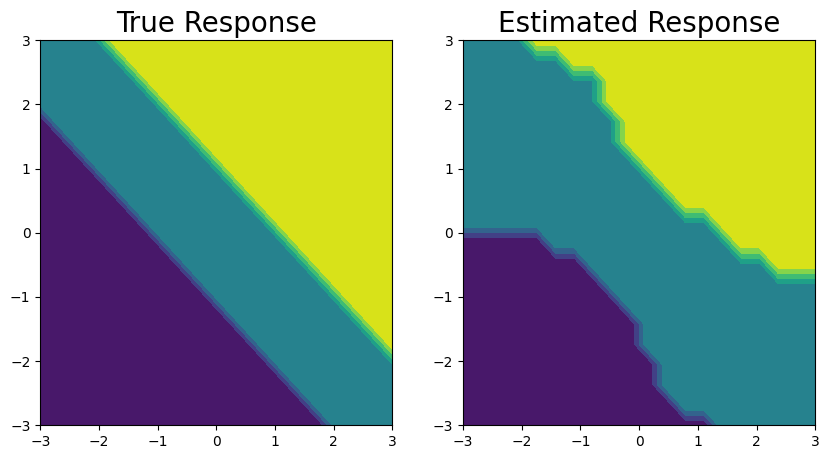

In [68]:
fig, ax = plt.subplots(1,2, figsize=(10, 5))

ax[0].contourf(test_x_mat.numpy(), test_y_mat.numpy(), test_labels.numpy())
ax[0].set_title('True Response', fontsize=20)

ax[1].contourf(test_x_mat.numpy(), test_y_mat.numpy(), prob_mean.argmax(dim=1).reshape((20,20)))
ax[1].set_title('Estimated Response', fontsize=20)
plt.show()